# <a id="#">Task 4 – Edge detection: Derivative operators</a>

In [78]:
import numpy as np
import matplotlib.pyplot as plt

---

## Prewitt filters

**<a id="#">Task 4.1.1.</a>** Load the image `data/astronaut.png` and show it:

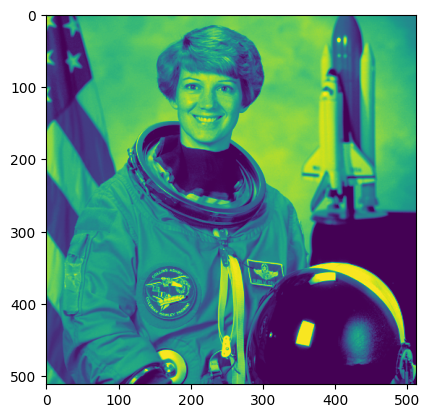

In [79]:
img=plt.imread('data/astronaut.png')
plt.imshow(img)

**<a id="#">Task 4.1.2.</a>** Implement horizontal and vertical 3&times;3 Prewitt filters:

In [80]:
h= np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
v= np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

def prewitt_h(img_in):
    result = np.zeros(img_in.shape)
    size= 3
    n = (size - 1) // 2
    

    for p in np.ndindex(img_in.shape):
        
        
        if p[0] >= n and p[1] >= n and p[0] < img_in.shape[0] - n and p[1] < img_in.shape[1] -n :
          
            neighborhood = img_in[p[0]-n:p[0]+n+1, p[1]-n:p[1]+n+1]
            
            result[p] = np.sum(neighborhood * h)/6
            
    return result

    
    
def prewitt_v(img_in):
    result = np.zeros(img_in.shape)
    size= 3
    n = (size - 1) // 2
    
    
    for p in np.ndindex(img_in.shape):
        
        
        if p[0] >= n and p[1] >= n and p[0] < img_in.shape[0] - n and p[1] < img_in.shape[1] -n :
          
            neighborhood = img_in[p[0]-n:p[0]+n+1, p[1]-n:p[1]+n+1]
            
            result[p] = np.sum(neighborhood * v)/6
            
    return result
            

**<a id="#">Task 4.1.3.</a>** Test your above solution using the functions `prewitt_h` and `prewitt_v` for the previously loaded image and show the result:

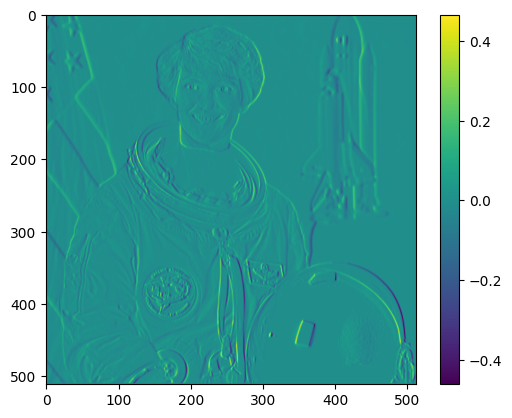

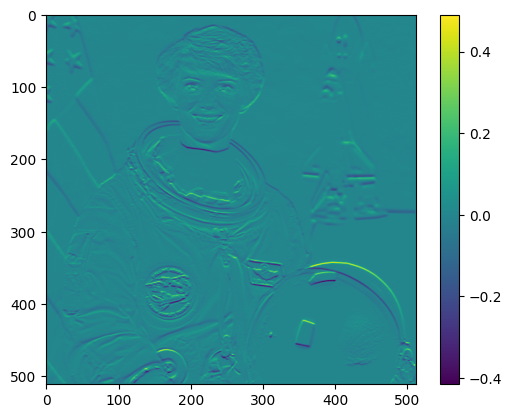

In [81]:
gx=prewitt_h(img)
gy=prewitt_v(img)

plt.figure()
plt.imshow(gx)
plt.colorbar()

plt.figure()
plt.imshow(gy)
plt.colorbar()

plt.show()




**<a id="#">Task 4.1.4.</a>** Compare your results with the correct result image `data/astronaut_prewitt_h.tiff` and `data/astronaut_prewitt_v.tiff`:

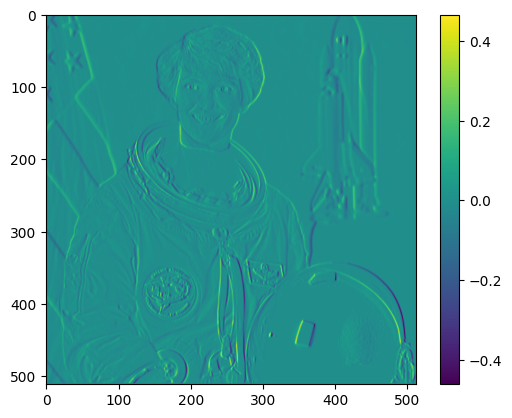

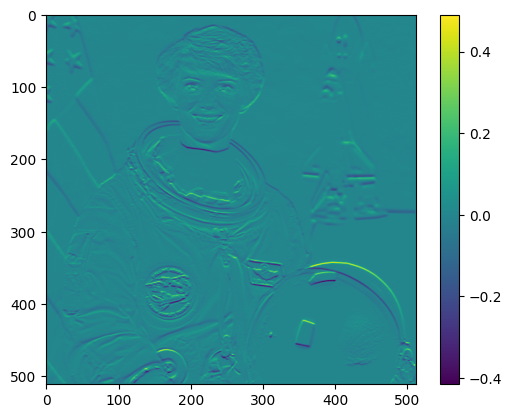

Maximale Differenz: 1.1102230246251565e-16
Durchschnittliche Differenz: 1.4987737905341371e-18
Maximale Differenz: 5.551115123125783e-17
Durchschnittliche Differenz: 1.622862063302525e-17


In [82]:
import skimage.io
a= skimage.io.imread('data/astronaut_prewitt_h.tiff')
b= skimage.io.imread('data/astronaut_prewitt_v.tiff')

plt.figure()
plt.imshow(a)
plt.colorbar()

plt.figure()
plt.imshow(b)
plt.colorbar()

plt.show()

diffx = np.abs(a - gx)
print("Maximale Differenz:", diffx.max())
print("Durchschnittliche Differenz:", diffx.mean())

diffy = np.abs(b - gy)
print("Maximale Differenz:", diffy.max())
print("Durchschnittliche Differenz:", diffy.mean())

assert np.allclose(a,gx, atol=1/255)

assert np.allclose(b,gy, atol=1/255)

---

## Edge detection

**<a id="#">Task 4.2.1.</a>** Use your results from **Task 4.1.2 – 4.1.3** to compute the *gradient magnitude* of the image:

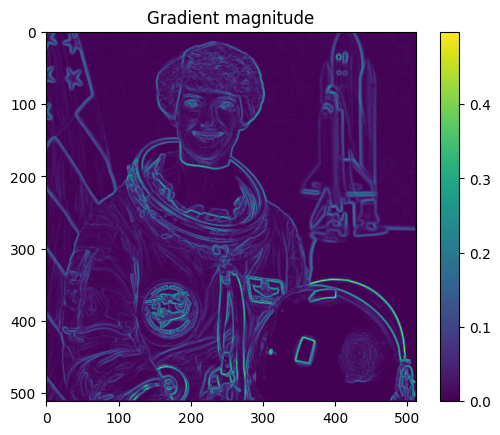

In [83]:
grad_mag = np.sqrt(gx**2 + gy**2)

plt.imshow(grad_mag)
plt.title("Gradient magnitude")
plt.colorbar()
plt.show()

**<a id="#">Task 4.2.2.</a>** Compare your result with the correct result image `data/astronaut_prewitt_gradmag.tiff`:

Maximale Differenz: 1.6653345369377348e-16
Durchschnittliche Differenz: 1.0400284002371495e-17


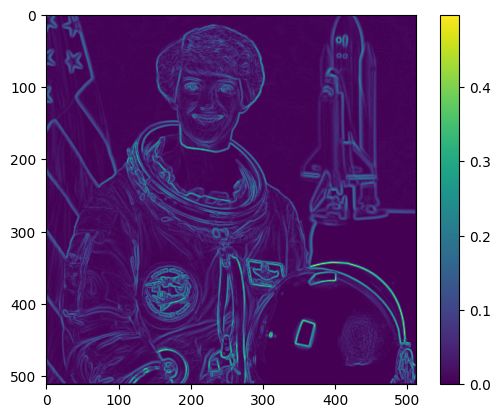

In [84]:
c= skimage.io.imread('data/astronaut_prewitt_gradmag.tiff')


plt.figure()
plt.imshow(c)
plt.colorbar()

diff = np.abs(c - grad_mag)
print("Maximale Differenz:", diff.max())
print("Durchschnittliche Differenz:", diff.mean())

assert np.allclose(c,grad_mag, atol=1/255)


---

## Sobel filters (bonus)

**<a id="#">Task 4.3.1.</a>** Implement the two functions `sobel_h` and `sobel_v` for horizontal and vertical 3&times;3 Sobel filtering, respectively:

In [85]:
h1= np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
v1= np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

def sobel_h(img_in):
    result = np.zeros(img_in.shape)
    size= 3
    n = (size - 1) // 2
    

    for p in np.ndindex(img_in.shape):
        
        
        if p[0] >= n and p[1] >= n and p[0] < img_in.shape[0] - n and p[1] < img_in.shape[1] -n :
          
            neighborhood = img_in[p[0]-n:p[0]+n+1, p[1]-n:p[1]+n+1]
            
            result[p] = np.sum(neighborhood * h1)/8
            
    return result

    
    
def sobel_v(img_in):
    result = np.zeros(img_in.shape)
    size= 3
    n = (size - 1) // 2
    
    
    for p in np.ndindex(img_in.shape):
        
        
        if p[0] >= n and p[1] >= n and p[0] < img_in.shape[0] - n and p[1] < img_in.shape[1] -n :
          
            neighborhood = img_in[p[0]-n:p[0]+n+1, p[1]-n:p[1]+n+1]
            
            result[p] = np.sum(neighborhood * v1)/8
            
    return result

**<a id="#">Task 4.3.2.</a>** Test your above solution using the functions `sobel_h` and `sobel_v` for the previously loaded image and show the result:

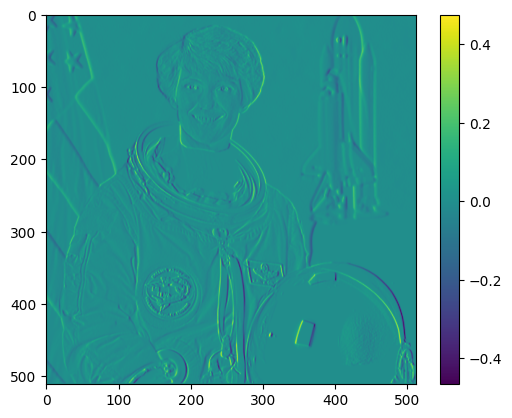

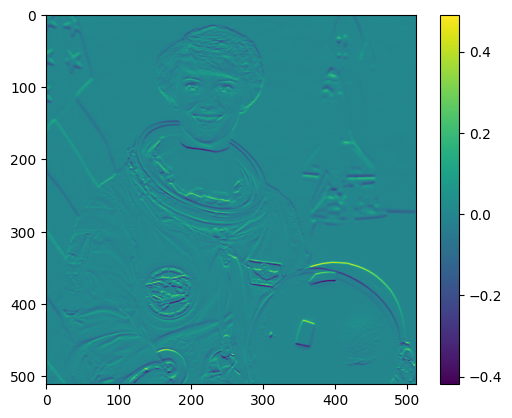

In [86]:
gx1=sobel_h(img)
gy1=sobel_v(img)

plt.figure()
plt.imshow(gx1)
plt.colorbar()

plt.figure()
plt.imshow(gy1)
plt.colorbar()

plt.show()

**<a id="#">Task 4.3.3.</a>** Compare your results with the correct result image `data/astronaut_sobel_h.tiff` and `data/astronaut_sobel_v.tiff`:

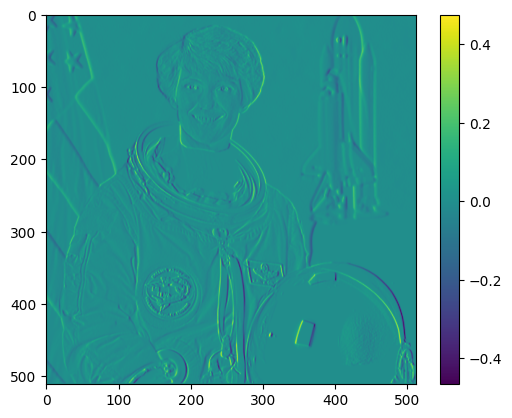

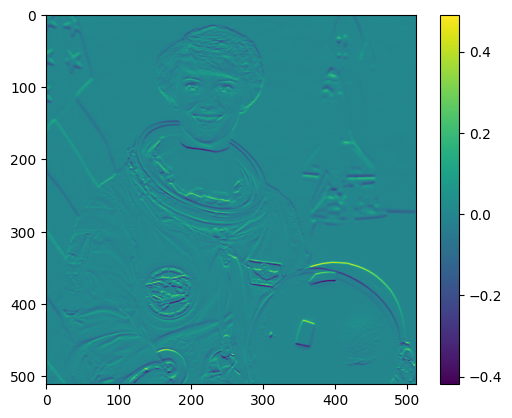

Maximale Differenz: 0.0
Durchschnittliche Differenz: 0.0
Maximale Differenz: 0.0
Durchschnittliche Differenz: 0.0


In [87]:
a1= skimage.io.imread('data/astronaut_sobel_h.tiff')
b1= skimage.io.imread('data/astronaut_sobel_v.tiff')

plt.figure()
plt.imshow(a1)
plt.colorbar()

plt.figure()
plt.imshow(b1)
plt.colorbar()

plt.show()

diffx1 = np.abs(a1 - gx1)
print("Maximale Differenz:", diffx1.max())
print("Durchschnittliche Differenz:", diffx1.mean())

diffy1 = np.abs(b1 - gy1)
print("Maximale Differenz:", diffy1.max())
print("Durchschnittliche Differenz:", diffy1.mean())

assert np.allclose(a1,gx1, atol=1/255)

assert np.allclose(b1,gy1, atol=1/255)